In [1]:
import h5py

In [3]:
f = h5py.File('/scratch/saporito/Frag3D/sim_vel1.0e+03_sf4.0e-01_T1.0e-05_k4.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00/data.h5', 'r')

In [4]:
list(f.keys())

['step_0',
 'step_1067',
 'step_1164',
 'step_1261',
 'step_1358',
 'step_1455',
 'step_1552',
 'step_1649',
 'step_1746',
 'step_1843',
 'step_194',
 'step_1940',
 'step_2037',
 'step_2134',
 'step_2231',
 'step_2328',
 'step_2425',
 'step_2522',
 'step_2619',
 'step_2716',
 'step_2813',
 'step_291',
 'step_2910',
 'step_3007',
 'step_3104',
 'step_3201',
 'step_3298',
 'step_3395',
 'step_3492',
 'step_3589',
 'step_3686',
 'step_3783',
 'step_388',
 'step_3880',
 'step_3977',
 'step_4074',
 'step_4171',
 'step_4268',
 'step_4365',
 'step_4462',
 'step_4559',
 'step_4656',
 'step_4753',
 'step_485',
 'step_4850',
 'step_4947',
 'step_5044',
 'step_5141',
 'step_5238',
 'step_5335',
 'step_5432',
 'step_5529',
 'step_5626',
 'step_5723',
 'step_582',
 'step_5820',
 'step_5917',
 'step_6014',
 'step_6111',
 'step_6208',
 'step_6305',
 'step_6402',
 'step_6499',
 'step_6596',
 'step_6693',
 'step_679',
 'step_6790',
 'step_6887',
 'step_6984',
 'step_7081',
 'step_7178',
 'step_7275',
 

In [5]:
final_step = f['step_9774']

In [6]:
print(final_step.attrs.keys())

<KeysViewHDF5 ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']>


In [8]:
final_masses = final_step['fragment_mass'][:]
final_velocities = final_step['fragment_velocity'][:]
print(final_masses)
print(final_velocities)

[1.35673146e-07 1.35673146e-07 1.35673146e-07 ... 5.99400054e-08
 5.99400054e-08 5.99400054e-08]
[[ 4.39287817e+02 -1.12225850e+01 -2.89832823e+00]
 [ 4.47923378e+02  5.56419554e+00  2.92650900e+00]
 [ 3.50611223e+02 -9.03148163e+00 -1.57360604e-01]
 ...
 [ 5.67571061e+01  9.59938357e+00 -4.82513287e+00]
 [ 4.99380187e+01  2.67612612e+00 -1.86587516e+01]
 [ 5.57677306e+01 -1.17134350e+01 -2.20742008e+00]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# print mean, min, max, std of masses and velocity magnitudes
mean_mass = np.mean(final_masses)
min_mass = np.min(final_masses)
max_mass = np.max(final_masses)
std_mass = np.std(final_masses)
velocity_magnitudes = np.linalg.norm(final_velocities, axis=1)
mean_velocity = np.mean(velocity_magnitudes)
min_velocity = np.min(velocity_magnitudes)
max_velocity = np.max(velocity_magnitudes)
std_velocity = np.std(velocity_magnitudes)
print(f"Masses - Mean: {mean_mass}, Min: {min_mass}, Max: {max_mass}, Std: {std_mass}")
print(f"Velocity Magnitudes - Mean: {mean_velocity}, Min: {min_velocity}, Max: {max_velocity}, Std: {std_velocity}")

Masses - Mean: 8.915567706958693e-08, Min: 1.7798380986813905e-08, Max: 7.4365351138807996e-06, Std: 3.5907979285090563e-07
Velocity Magnitudes - Mean: 316.1160372947512, Min: 2.1428380653600927, Max: 15778.103149331711, Std: 473.36539931780453


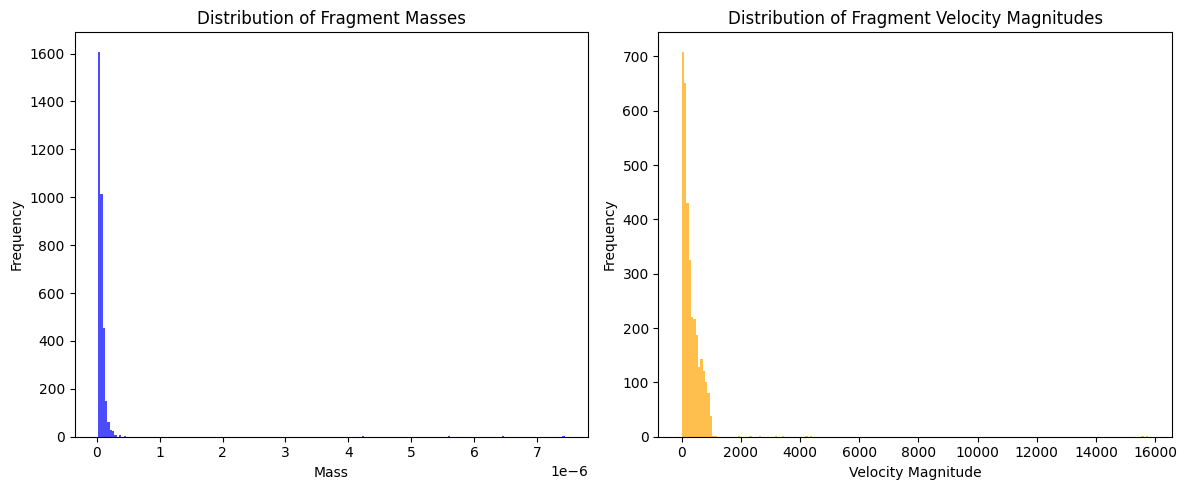

In [12]:
# distribution of masses and velocity magnitudes, really tight bins to see the distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(final_masses, bins=200, color='blue', alpha=0.7)
plt.title('Distribution of Fragment Masses')
plt.xlabel('Mass')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(velocity_magnitudes, bins=200, color='orange', alpha=0.7)
plt.title('Distribution of Fragment Velocity Magnitudes')
plt.xlabel('Velocity Magnitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [13]:
import pyvista as pv

/tmp/ipykernel_3640855/4019022572.py:10: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


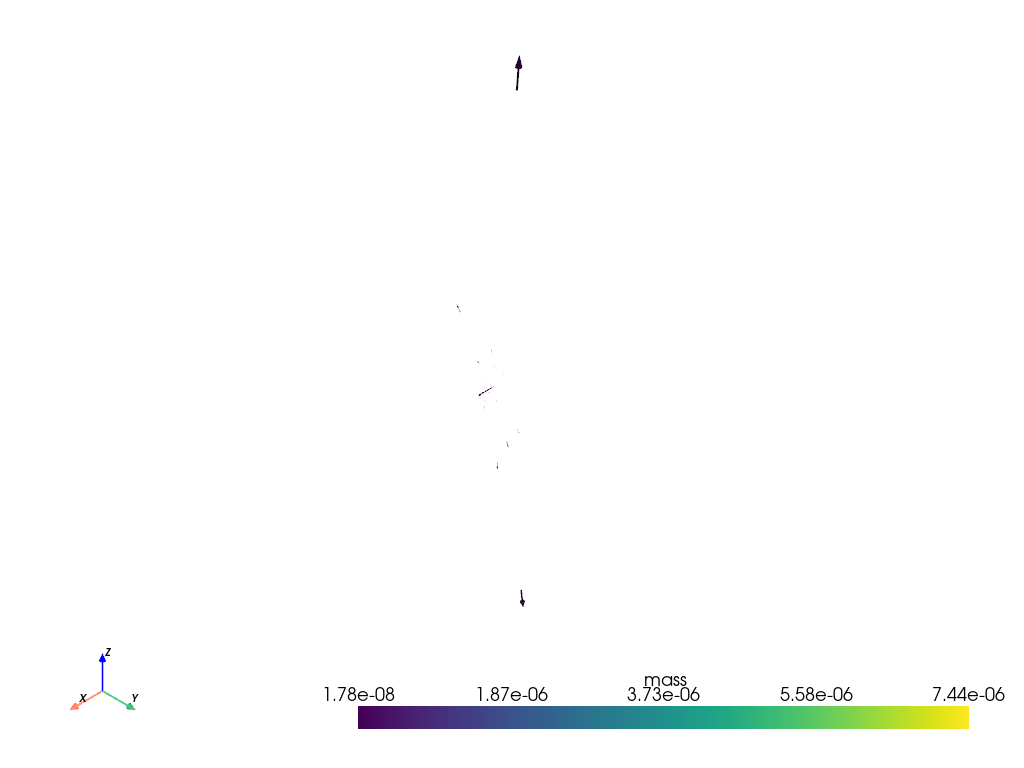

In [ ]:
# paraview glyphs of output velocities, colored by mass and length by magnitude velocity
#point_cloud = pv.PolyData(final_COM)
point_cloud['velocity'] = final_velocities
point_cloud['mass'] = final_masses
point_cloud['velocity_magnitude'] = velocity_magnitudes
glyphs = point_cloud.glyph(orient='velocity', scale='velocity_magnitude', factor=0.1)
plotter = pv.Plotter()
plotter.add_mesh(glyphs, scalars='mass', cmap='viridis', show_scalar_bar=True)
plotter.add_axes()
plotter.show()